In [7]:
# นำเข้าไลบรารีพื้นฐานสำหรับการจัดการข้อมูล
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

# ดาวน์โหลดชุดคำฟุ่มเฟือย (Stopwords)
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# โหลดข้อมูลจากไฟล์ spam.csv
df = pd.read_csv('spam.csv', encoding='latin-1')

# ดูหน้าตาข้อมูลเบื้องต้น
print("ข้อมูลก่อนทำความสะอาด:")
print(df.head())



ข้อมูลก่อนทำความสะอาด:
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
# ลบคอลัมน์ที่ไม่มีข้อมูล (v3, v4, v5) ทิ้งไป
df = df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, errors='ignore')

# เปลี่ยนชื่อคอลัมน์ให้เข้าใจง่ายขึ้น (v1 -> label, v2 -> message)
df.columns = ['label', 'message']

print("\nข้อมูลหลังจัดการคอลัมน์:")
print(df.head())


ข้อมูลหลังจัดการคอลัมน์:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [9]:
# ดูจำนวนข้อความทั้งหมด
print("ขนาดของข้อมูล (แถว, คอลัมน์):", df.shape)

ขนาดของข้อมูล (แถว, คอลัมน์): (5572, 2)


In [10]:
# ตรวจสอบว่ามีข้อมูลสูญหาย (Missing values) หรือไม่
print("\nจำนวนข้อมูลที่สูญหายในแต่ละคอลัมน์:\n", df.isnull().sum())


จำนวนข้อมูลที่สูญหายในแต่ละคอลัมน์:
 label      0
message    0
dtype: int64


In [11]:
# ดูสัดส่วนระหว่างคลาส Ham (ข้อความปกติ) และ Spam
print("\nจำนวนข้อความในแต่ละคลาส:")
print(df['label'].value_counts())



จำนวนข้อความในแต่ละคลาส:
label
ham     4825
spam     747
Name: count, dtype: int64


/tmp/ipython-input-603/1281323604.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='Set2')


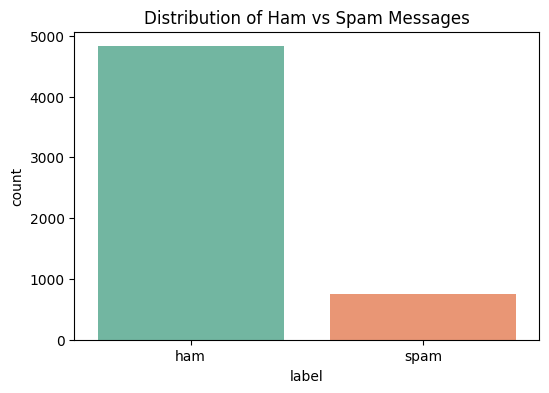

In [12]:
# พล็อตกราฟแท่งเพื่อดูสัดส่วน
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label', palette='Set2')
plt.title('Distribution of Ham vs Spam Messages')
plt.show()

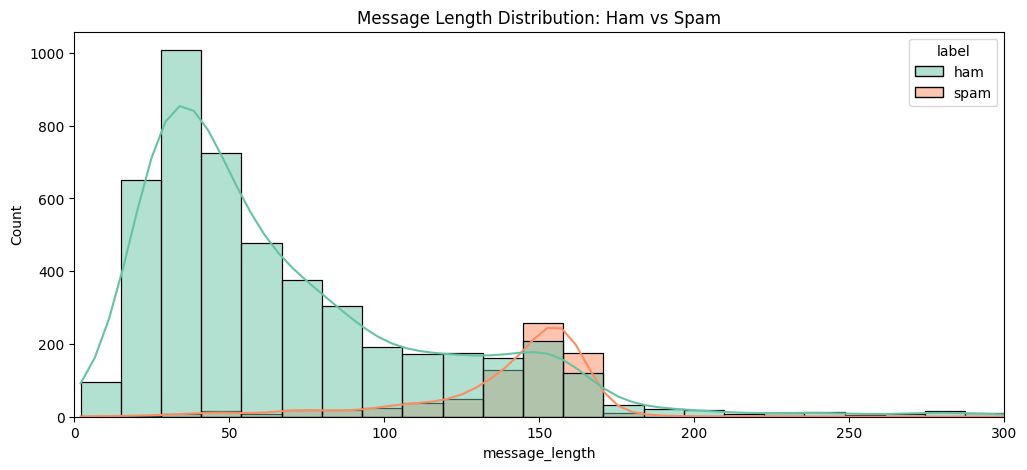

In [13]:
# สร้างคอลัมน์ใหม่เพื่อดู "ความยาวของข้อความ"
df['message_length'] = df['message'].apply(len)

# พล็อตกราฟดูการกระจายตัวของความยาวข้อความ
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='message_length', hue='label', bins=70, kde=True, palette='Set2')
plt.title('Message Length Distribution: Ham vs Spam')
plt.xlim(0, 300) # จำกัดแกน x ไม่ให้ยาวเกินไป
plt.show()

In [14]:
# ฟังก์ชันทำความสะอาดข้อความ
def clean_text(text):
    text = text.lower() # แปลงเป็นตัวพิมพ์เล็ก
    text = re.sub(r'[^a-z\s]', '', text) # ลบตัวเลข เครื่องหมายวรรคตอน เก็บแค่ a-z
    # ตัดคำและลบ Stopwords (เช่น is, am, the)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words) # ประกอบคำกลับเป็นประโยค

# ประยุกต์ใช้ฟังก์ชันทำความสะอาดกับคอลัมน์ message
df['cleaned_message'] = df['message'].apply(clean_text)

# แปลง Label จากข้อความให้เป็นตัวเลข (Ham = 0, Spam = 1)
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

# แปลงข้อความเป็นตัวเลข (Vector) ด้วยวิธี TF-IDF
# max_features=3000 คือเลือกเฉพาะคำที่พบบ่อย 3000 คำแรก เพื่อลดขนาดข้อมูล
vectorizer = TfidfVectorizer(max_features=3000)
X = vectorizer.fit_transform(df['cleaned_message']).toarray() # ตัวแปรต้น (Features)
y = df['label_num'].values # ตัวแปรตาม (Target)

print(f"แปลงข้อความเป็นตัวเลขเรียบร้อย! ขนาดของข้อมูลคือ: {X.shape}")

แปลงข้อความเป็นตัวเลขเรียบร้อย! ขนาดของข้อมูลคือ: (5572, 3000)


In [15]:
from sklearn.model_selection import train_test_split

# แบ่งข้อมูล X และ y
# test_size=0.2 คือแบ่งไป Test 20%
# random_state=42 เพื่อล็อกผลการสุ่มให้เหมือนเดิมทุกครั้งที่รันโค้ด
# stratify=y เพื่อให้สัดส่วนของ Spam/Ham ในชุด Train และ Test เท่าๆ กัน
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"จำนวนข้อมูลสำหรับเทรน (Train): {X_train.shape[0]} ตัวอย่าง")
print(f"จำนวนข้อมูลสำหรับทดสอบ (Test): {X_test.shape[0]} ตัวอย่าง")

จำนวนข้อมูลสำหรับเทรน (Train): 4457 ตัวอย่าง
จำนวนข้อมูลสำหรับทดสอบ (Test): 1115 ตัวอย่าง


In [17]:
from sklearn.naive_bayes import MultinomialNB

# สร้างตัวแบบ (Model)
model = MultinomialNB()

# สั่งให้โมเดลเรียนรู้ (Train) จากชุดข้อมูล X_train และ y_train
model.fit(X_train, y_train)

# ให้โมเดลทำนายผลลัพธ์จากชุดข้อมูลทดสอบ X_test ที่มันไม่เคยเห็นมาก่อน
y_pred = model.predict(X_test)

print("ฝึกสอนโมเดลและทำการทำนายผลสำเร็จ!")

ฝึกสอนโมเดลและทำการทำนายผลสำเร็จ!


In [18]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# คำนวณความแม่นยำรวม (Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"ความแม่นยำของโมเดล (Accuracy): {accuracy * 100:.2f}%\n")

# ดูรายงานเชิงลึก (Precision, Recall, F1-Score)
print("--- รายงานการจำแนกประเภท (Classification Report) ---")
print(classification_report(y_test, y_pred, target_names=['Ham (0)', 'Spam (1)']))



ความแม่นยำของโมเดล (Accuracy): 97.04%

--- รายงานการจำแนกประเภท (Classification Report) ---
              precision    recall  f1-score   support

     Ham (0)       0.97      1.00      0.98       966
    Spam (1)       0.99      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



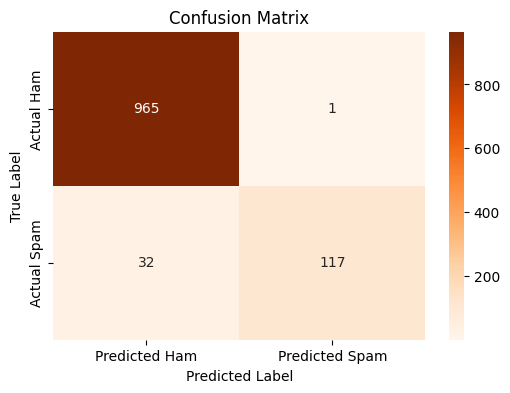

In [19]:
# วาดกราฟ Confusion Matrix เพื่อดูการทายถูก/ผิด ในแต่ละประเภท
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# ==========================================
# 1. Logistic Regression Model
# ==========================================
print("=== ผลลัพธ์จากโมเดล Logistic Regression ===")
# สร้างและฝึกสอนโมเดล
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train, y_train)

# ทำนายและประเมินผล
y_pred_log = log_model.predict(X_test)
acc_log = accuracy_score(y_test, y_pred_log)
print(f"ความแม่นยำ (Accuracy): {acc_log * 100:.2f}%")
print(classification_report(y_test, y_pred_log, target_names=['Ham (0)', 'Spam (1)']))
print("-" * 50, "\n")

=== ผลลัพธ์จากโมเดล Logistic Regression ===
ความแม่นยำ (Accuracy): 96.14%
              precision    recall  f1-score   support

     Ham (0)       0.96      1.00      0.98       966
    Spam (1)       0.98      0.72      0.83       149

    accuracy                           0.96      1115
   macro avg       0.97      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115

-------------------------------------------------- 



In [21]:
# ==========================================
# 2. Support Vector Machine (SVM) Model
# ==========================================
print("=== ผลลัพธ์จากโมเดล Support Vector Machine (SVM) ===")
# สร้างและฝึกสอนโมเดล (ใช้ kernel='linear' มักจะทำงานได้ดีกับข้อมูลข้อความ Text)
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

# ทำนายและประเมินผล
y_pred_svm = svm_model.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"ความแม่นยำ (Accuracy): {acc_svm * 100:.2f}%")
print(classification_report(y_test, y_pred_svm, target_names=['Ham (0)', 'Spam (1)']))
print("-" * 50, "\n")

=== ผลลัพธ์จากโมเดล Support Vector Machine (SVM) ===
ความแม่นยำ (Accuracy): 98.48%
              precision    recall  f1-score   support

     Ham (0)       0.98      1.00      0.99       966
    Spam (1)       1.00      0.89      0.94       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.97      1115
weighted avg       0.99      0.98      0.98      1115

-------------------------------------------------- 



In [22]:
# ==========================================
# 3. เปรียบเทียบประสิทธิภาพทั้ง 3 โมเดล
# ==========================================
# ดึงค่า accuracy ของ Naive Bayes จากตัวแปรเดิม (ถ้าคุณรัน cell ก่อนหน้ามาแล้ว)
acc_nb = accuracy_score(y_test, model.predict(X_test))

print("=== 🏆 สรุปเปรียบเทียบความแม่นยำ (Accuracy) ===")
print(f"1. Naive Bayes:        {acc_nb * 100:.2f}%")
print(f"2. Logistic Regression: {acc_log * 100:.2f}%")
print(f"3. SVM (Linear):       {acc_svm * 100:.2f}%")

=== 🏆 สรุปเปรียบเทียบความแม่นยำ (Accuracy) ===
1. Naive Bayes:        97.04%
2. Logistic Regression: 96.14%
3. SVM (Linear):       98.48%
